# Dataset 1 (Seeds) - Edge Detection Parameter Experimentation
Use this notebook to load individual images from Dataset 1 and dynamically test different parameters for Preprocessing, Canny, and Sobel edge detection.

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# Import our existing pipeline code
from baseline_code.preprocessing import load_config, apply_grayscale, apply_noise_reduction
from edge_detection import apply_canny, apply_sobel, extract_contours_and_features, count_objects_from_contours

In [18]:
# --- CONFIGURATION ---
IMAGE_NAME = '132.jpg' # Change this to any seed image name (e.g., '14.jpg', '50.jpg')
DATA_DIR = 'data/'
CONFIG_PATH = 'baseline_code/config.yaml'

# Load image and config
cfg = load_config(CONFIG_PATH)
img_path = os.path.join(DATA_DIR, IMAGE_NAME)
image = cv2.imread(img_path)

if image is None:
    print(f"Error: Could not find {img_path}")
else:
    print(f"Loaded {IMAGE_NAME} with shape {image.shape}")

Loaded 132.jpg with shape (3024, 3024, 3)


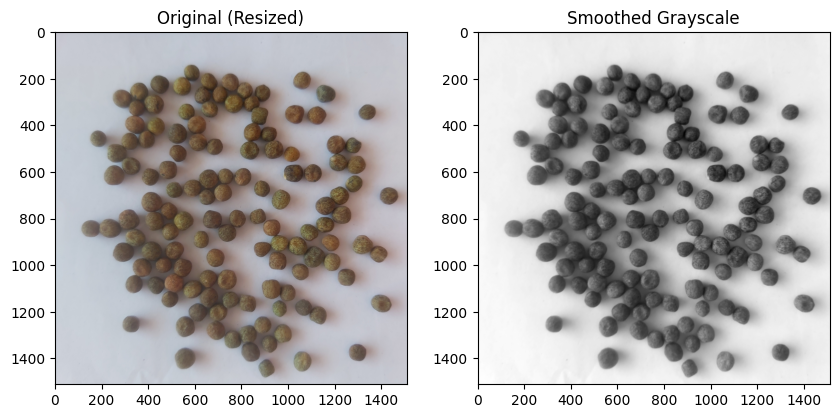

In [19]:
# 1. Downsampling (Matching our processing script)
RESIZE_FACTOR = 0.5
h, w = image.shape[:2]
new_w, new_h = int(w * RESIZE_FACTOR), int(h * RESIZE_FACTOR)
image_resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

# 2. Preprocessing
gray = apply_grayscale(image_resized)
smoothed = apply_noise_reduction(gray, cfg, method="gaussian")

# Display intermediate steps
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original (Resized)")
ax[1].imshow(smoothed, cmap='gray')
ax[1].set_title("Smoothed Grayscale")
plt.show()

## Canny Edge Detection
Try tweaking the `low_thresh` and `high_thresh` values below!

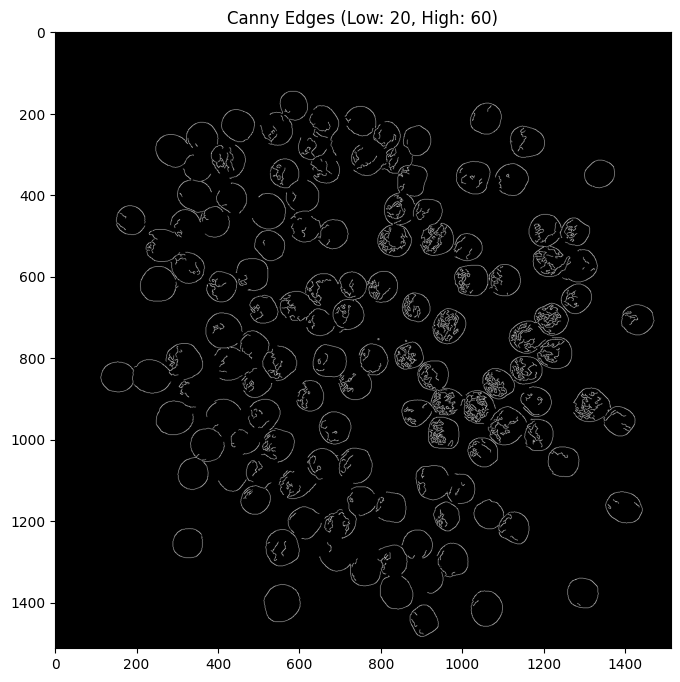

In [20]:
# --- CANNY EXPERIMENTATION PARAMETERS ---
LOW_THRESH = 20
HIGH_THRESH = 60

canny_edges = apply_canny(smoothed, low_thresh=LOW_THRESH, high_thresh=HIGH_THRESH)

plt.figure(figsize=(8, 8))
plt.imshow(canny_edges, cmap='gray')
plt.title(f"Canny Edges (Low: {LOW_THRESH}, High: {HIGH_THRESH})")
plt.show()

## Sobel Edge Detection
Try tweaking `ksize` (must be odd, 1, 3, 5, 7) or the threshold applied to the floating-point magnitude map

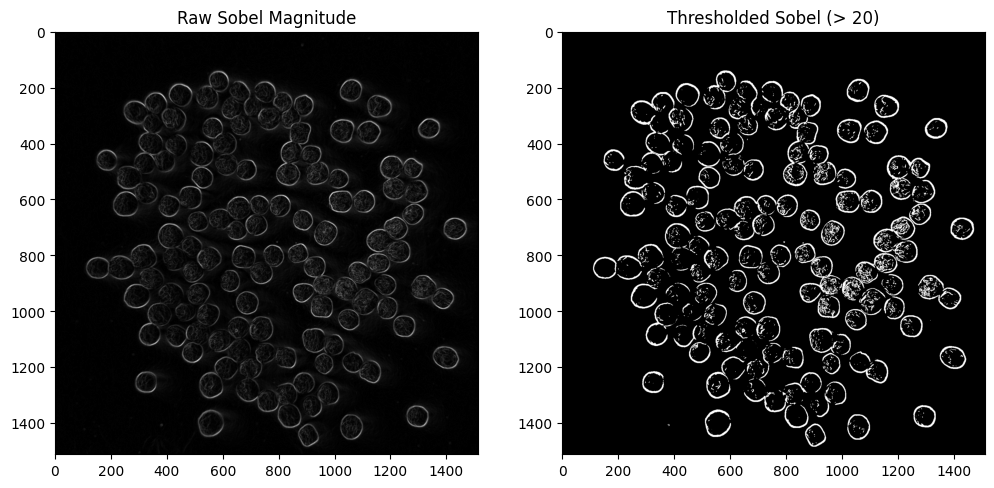

In [21]:
# --- SOBEL EXPERIMENTATION PARAMETERS ---
SOBEL_KSIZE = 3
SOBEL_BINARY_THRESH = 20  # Turning raw gradients into a binary mask

_, _, sobel_edges = apply_sobel(smoothed, ksize=SOBEL_KSIZE)
_, sobel_binary = cv2.threshold(sobel_edges, SOBEL_BINARY_THRESH, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(sobel_edges, cmap='gray')
ax[0].set_title("Raw Sobel Magnitude")
ax[1].imshow(sobel_binary, cmap='gray')
ax[1].set_title(f"Thresholded Sobel (> {SOBEL_BINARY_THRESH})")
plt.show()

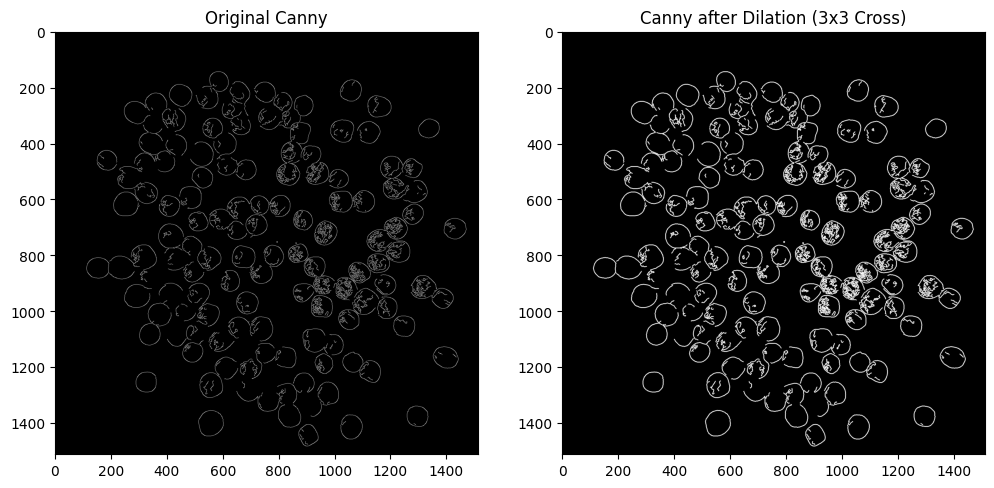

In [22]:
# --- MORPHOLOGY EX3: DILATION ---
import cv2
import matplotlib.pyplot as plt

kernel_dilate = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

# Thicken every edge line
canny_dilated = cv2.dilate(canny_edges, kernel_dilate, iterations=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(canny_edges, cmap='gray')
ax[0].set_title("Original Canny")
ax[1].imshow(canny_dilated, cmap='gray')
ax[1].set_title("Canny after Dilation (3x3 Cross)")
plt.show()

# (If you like this, use 'canny_dilated' in the final extraction step instead of 'canny_edges')


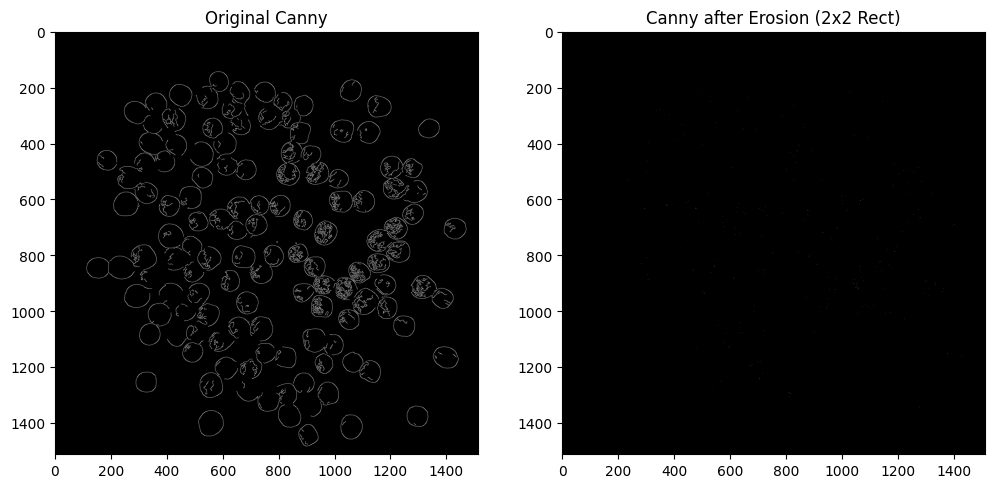

In [25]:
# --- MORPHOLOGY EX4: EROSION (Shrinking) ---
import cv2
import matplotlib.pyplot as plt

# Using a very small 2x2 or 3x3 kernel, otherwise you'll erase the whole image!
kernel_erode = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))

# Erode eats away the boundaries of foreground objects (white pixels)
canny_eroded = cv2.erode(canny_edges, kernel_erode, iterations=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(canny_edges, cmap='gray')
ax[0].set_title("Original Canny")
ax[1].imshow(canny_eroded, cmap='gray')
ax[1].set_title("Canny after Erosion (2x2 Rect)")
plt.show()

# (If you like this, use 'canny_eroded' in the final extraction step instead of 'canny_edges')


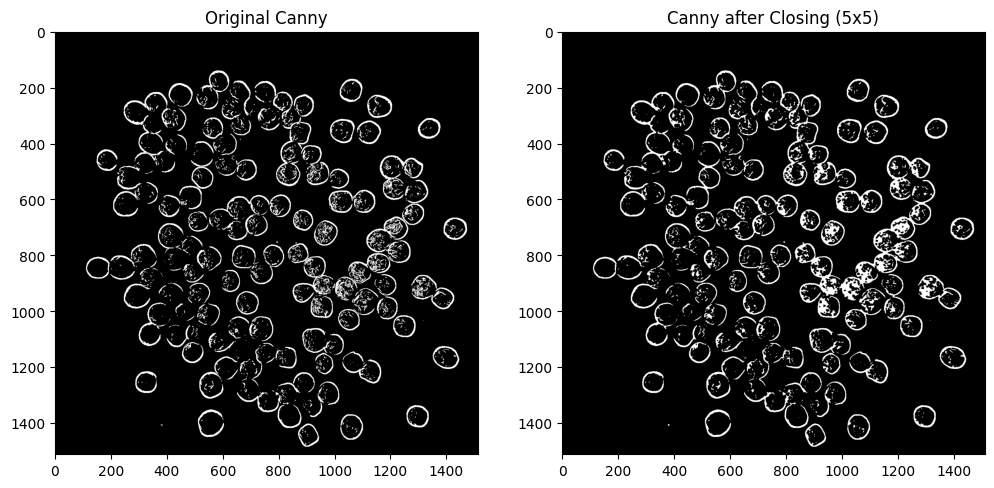

In [46]:
# --- MORPHOLOGY EX1: CLOSING ---
import cv2
import matplotlib.pyplot as plt

# A 5x5 ellipse kernel works well for round seeds
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Closing = Dilation followed by Erosion. It "closes" small gaps.
sobel_closed = cv2.morphologyEx(sobel_binary, cv2.MORPH_CLOSE, kernel_close)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(sobel_binary, cmap='gray')
ax[0].set_title("Original Canny")
ax[1].imshow(sobel_closed, cmap='gray')
ax[1].set_title("Canny after Closing (5x5)")
plt.show()

# (If you like this, use 'canny_closed' in the final extraction step instead of 'canny_edges')


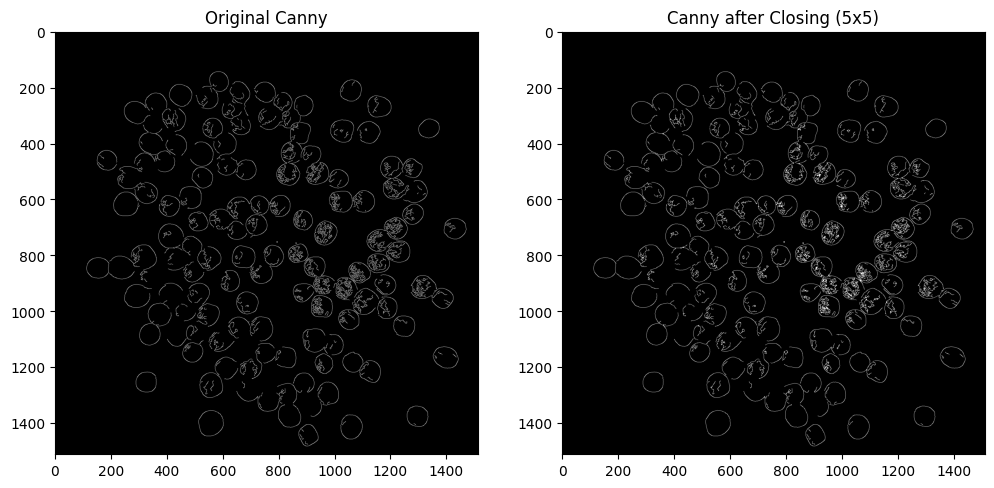

In [36]:
# --- MORPHOLOGY EX1: CLOSING ---
import cv2
import matplotlib.pyplot as plt

# A 5x5 ellipse kernel works well for round seeds
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# Closing = Dilation followed by Erosion. It "closes" small gaps.
canny_closed = cv2.morphologyEx(canny_edges, cv2.MORPH_CLOSE, kernel_close)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(canny_edges, cmap='gray')
ax[0].set_title("Original Canny")
ax[1].imshow(canny_closed, cmap='gray')
ax[1].set_title("Canny after Closing (5x5)")
plt.show()

# (If you like this, use 'canny_closed' in the final extraction step instead of 'canny_edges')


## Evaluate & Count
Let's extract the contours and run our area threshold count based on the edge maps generated above.

Canny Predicted Count: 64
Sobel Predicted Count: 74


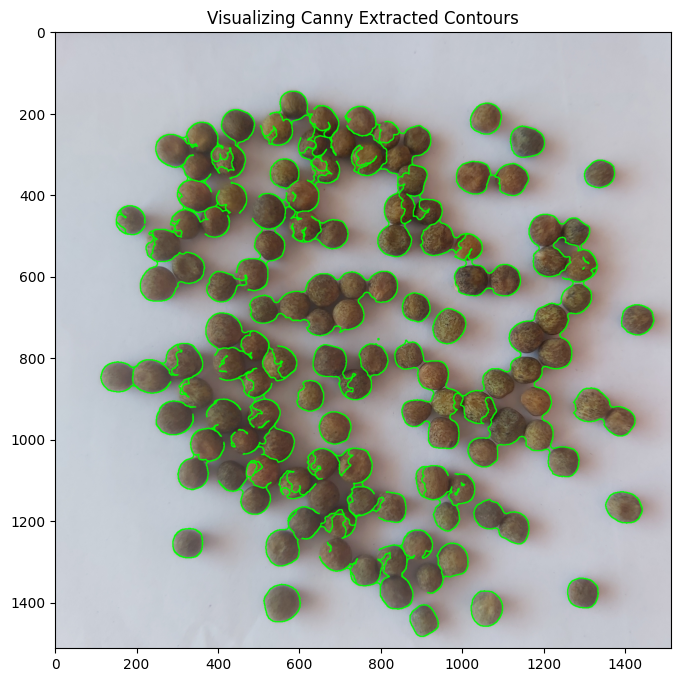

In [48]:
# Extract features (function only returns a single features list now)
canny_features = extract_contours_and_features(canny_closed)
sobel_features = extract_contours_and_features(sobel_closed)

# Scale thresholds by resize factor 
scaled_min_area = (cfg.get("blob_detection", {}).get("min_area", 8000) * (RESIZE_FACTOR ** 2)) / 2
scaled_max_area = cfg.get("blob_detection", {}).get("max_area", 200000) * (RESIZE_FACTOR ** 2)

canny_count = count_objects_from_contours(canny_features, min_area=scaled_min_area, max_area=scaled_max_area, min_circ=0.2)
sobel_count = count_objects_from_contours(sobel_features, min_area=scaled_min_area, max_area=scaled_max_area, min_circ=0.2)

print(f"Canny Predicted Count: {canny_count}")
print(f"Sobel Predicted Count: {sobel_count}")

# Draw the Canny Contours explicitly in Green
vis_image = image_resized.copy()
canny_contours_to_draw = [f['contour'] for f in canny_features]
cv2.drawContours(vis_image, canny_contours_to_draw, -1, (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title("Visualizing Canny Extracted Contours")
plt.show()


Total Canny Predicted Count: 93


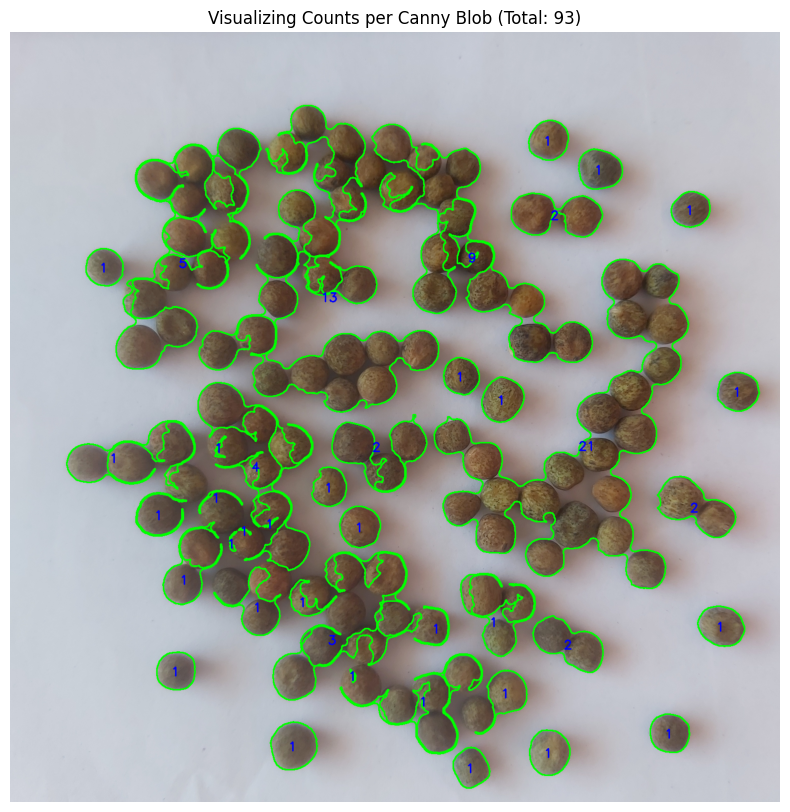

In [54]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Extract features
canny_features = extract_contours_and_features(canny_dilated)
sobel_features = extract_contours_and_features(sobel_closed)

# Scale thresholds by resize factor 
scaled_min_area = (cfg.get("blob_detection", {}).get("min_area", 8000) * (RESIZE_FACTOR ** 2)) / 2
scaled_max_area = cfg.get("blob_detection", {}).get("max_area", 200000) * (RESIZE_FACTOR ** 2)

# --- Find typical area for Canny (Same logic as our python script) ---
valid_areas = []
for f in canny_features:
    if scaled_min_area <= f['area'] <= scaled_max_area and f['circularity'] >= 0.2:
        valid_areas.append(f['area'])
typical_area = float(np.median(valid_areas)) if valid_areas else float(scaled_min_area * 1.5)

# Build final counts and prepare visualization
vis_image = image_resized.copy()
total_canny_count = 0

for f in canny_features:
    area = f['area']
    cnt = f['contour']
    is_valid = False
    blob_count = 0
    
    if area < 50:
        continue
        
    # 1. Determine if it's a valid shape and how many seeds it represents
    # Overlapping cluster: check if it's much larger than a typical single seed
    if area > 1.6 * typical_area or area > scaled_max_area:
        blob_count = max(1, round(area / typical_area))
        is_valid = True
    elif f['circularity'] >= 0.0:
        blob_count = 1
        is_valid = True
        
    # 2. If it's valid, draw it and add the number!
    if is_valid:
        total_canny_count += int(blob_count)
        
        # Draw the outline in Green
        cv2.drawContours(vis_image, [cnt], -1, (0, 255, 0), 2)
        
        # Find the center of the contour to place the text
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
        else:
            cX, cY = cnt[0][0][0], cnt[0][0][1]
            
        # Write the number in Red text
        cv2.putText(vis_image, str(int(blob_count)), (cX - 10, cY + 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

print(f"Total Canny Predicted Count: {total_canny_count}")

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title(f"Visualizing Counts per Canny Blob (Total: {total_canny_count})")
plt.axis('off')
plt.show()
